In [1]:
!pip install tensorflow-hub
!pip install --upgrade keras-cv

**Imports**

In [2]:
import os
import glob
import cv2
import pywt
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# CHANGED: ResNet50 and ConvNeXt Imports
# IMPORT [Model]
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# IMPORT ViT
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

2026-04-12 08:22:11.887047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775982132.224015      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775982132.320561      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775982133.181572      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775982133.181614      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775982133.181617      55 computation_placer.cc:177] computation placer alr

**Data Loading and Splitting**

In [3]:
# CHANGE: Update path and label parsing for Multi-Cancer

database_path = '/kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer'

image_paths = glob.glob(os.path.join(database_path, '**', '*.*'), recursive=True)
image_paths = [p for p in image_paths if p.lower().endswith(('.bmp', '.jpg', '.png'))]

# Multi-Cancer folders are already named cervix_koc etc, no 'im_' prefix to remove
labels = [path.split('/')[-2] for path in image_paths]

df = pd.DataFrame({'filename': image_paths, 'label': labels})

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_encoded'], random_state=42)

print(f"Total images found: {len(df)}")
print("Training Set Distribution:\n", train_df['label'].value_counts())

Total images found: 25000
Training Set Distribution:
 label
cervix_koc    4000
cervix_pab    4000
cervix_dyk    4000
cervix_mep    4000
cervix_sfi    4000
Name: count, dtype: int64


**Image Data Generators**

In [4]:
# CHANGED: Using 224x224 for optimal ResNet50 and ConvNeXt performance
IMG_SIZE = 224  
BATCH_SIZE = 32

# CHANGE: VGG16 generators (was rn_datagen with resnet_preprocess)
rn_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess)
rn_train_gen = rn_datagen.flow_from_dataframe(train_df, x_col='filename', y_col='label', target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)
rn_test_gen  = rn_datagen.flow_from_dataframe(test_df, x_col='filename', y_col='label', target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)

print("\n--- Extracting VGG16 Features (Local CNN) ---")
# CHANGE: VGG16 — outputs 512 features (was ResNet50 with 2048)
rn_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
rn_extractor = Model(inputs=rn_base.input, outputs=GlobalAveragePooling2D()(rn_base.output))
X_train_rn = rn_extractor.predict(rn_train_gen, verbose=1)
X_test_rn  = rn_extractor.predict(rn_test_gen, verbose=1)

# 2. ConvNeXt Generators
cn_datagen = ImageDataGenerator(preprocessing_function=convnext_preprocess)
cn_train_gen = cn_datagen.flow_from_dataframe(train_df, x_col='filename', y_col='label', target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)
cn_test_gen  = cn_datagen.flow_from_dataframe(test_df, x_col='filename', y_col='label', target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)

print("\n--- Extracting ConvNeXt Features (Global Transformer-CNN) ---")
cn_base = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
cn_extractor = Model(inputs=cn_base.input, outputs=GlobalAveragePooling2D()(cn_base.output))
X_train_cn = cn_extractor.predict(cn_train_gen, verbose=1)
X_test_cn  = cn_extractor.predict(cn_test_gen, verbose=1)

print("\n--- Fusing Deep Features ---")
# Combine ResNet50 (2048) + ConvNeXt (768) = 2816 Total
# Keeping original variable names so the PCA cell runs automatically!
X_train_deep = np.hstack((X_train_rn, X_train_cn))
X_test_deep  = np.hstack((X_test_rn, X_test_cn))

print(f"Master Deep features shape: {X_train_deep.shape}")

Found 20000 validated image filenames belonging to 5 classes.
Found 5000 validated image filenames belonging to 5 classes.

--- Extracting VGG16 Features (Local CNN) ---


I0000 00:00:1775982227.647003      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1775982233.017280     115 service.cc:152] XLA service 0x7b099c0046e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775982233.017329     115 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775982233.233802     115 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step  

I0000 00:00:1775982241.366511     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 308ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step
Found 20000 validated image filenames belonging to 5 classes.
Found 5000 validated image filenames belonging to 5 classes.

--- Extracting ConvNeXt Features (Global Transformer-CNN) ---
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 84ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step

--- Fusing Deep Features ---
Master Deep features shape: (20000, 1280)


# PCA

In [5]:
# Compress the 2048 Xception features down to 128
pca = PCA(n_components=128, random_state=42)

# Make sure these names match exactly what Xception outputted!
X_train_deep_pca = pca.fit_transform(X_train_deep)
X_test_deep_pca  = pca.transform(X_test_deep)

print(f"Reduced Deep features shape: {X_train_deep_pca.shape}")

Reduced Deep features shape: (20000, 128)


# Handcrafted Feature Extraction

In [6]:
def extract_handcrafted_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(40)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    coeffs2 = pywt.dwt2(img, 'haar')
    LL, (LH, HL, HH) = coeffs2
    dwt_features = [
        np.mean(LL), np.std(LL),
        np.mean(LH), np.std(LH),
        np.mean(HL), np.std(HL),
        np.mean(HH), np.std(HH)
    ]
    
    glcm = graycomatrix(img, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
                        levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()
    
    glcm_features = np.concatenate([contrast, correlation, energy, homogeneity])
    
    return np.concatenate([dwt_features, glcm_features])

print("Extracting GLCM & DWT features for Training data...")
hc_features_train = np.array([extract_handcrafted_features(p) for p in tqdm(train_df['filename'])])

print("Extracting GLCM & DWT features for Test data...")
hc_features_test = np.array([extract_handcrafted_features(p) for p in tqdm(test_df['filename'])])

Extracting GLCM & DWT features for Training data...


100%|██████████| 20000/20000 [12:22<00:00, 26.94it/s]


Extracting GLCM & DWT features for Test data...


100%|██████████| 5000/5000 [03:07<00:00, 26.68it/s]


# Feature

In [7]:
# Notice we are fusing the PCA-reduced features now
X_train_fused = np.hstack((X_train_deep_pca, hc_features_train))
X_test_fused = np.hstack((X_test_deep_pca, hc_features_test))

y_train = train_df['label_encoded'].values
y_test = test_df['label_encoded'].values

print(f"Optimized Fused Training Data Shape: {X_train_fused.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fused)
X_test_scaled = scaler.transform(X_test_fused)

Optimized Fused Training Data Shape: (20000, 168)


**Model Training**

In [17]:
print("Training Optimized XGBoost Classifier...")

# Calculate sample weights to handle any class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=5, 
    eval_metric=['mlogloss', 'merror'], 
    use_label_encoder=False,
    n_estimators=300,        # Increased trees
    learning_rate=0.03,      # Lower learning rate for better convergence
    max_depth=5,             # Reduced depth to prevent overfitting
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.5,          # L2 Regularization to fight overfitting
    n_jobs=-1 
)

xgb_model.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights, # Apply weights here
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=20
)

print("Training Complete!")

Training Optimized XGBoost Classifier...
[0]	validation_0-mlogloss:1.56313	validation_0-merror:0.16220	validation_1-mlogloss:1.56401	validation_1-merror:0.17760


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[20]	validation_0-mlogloss:0.98220	validation_0-merror:0.07380	validation_1-mlogloss:0.99237	validation_1-merror:0.08240
[40]	validation_0-mlogloss:0.67895	validation_0-merror:0.05635	validation_1-mlogloss:0.69473	validation_1-merror:0.06640
[60]	validation_0-mlogloss:0.49378	validation_0-merror:0.04515	validation_1-mlogloss:0.51363	validation_1-merror:0.05540
[80]	validation_0-mlogloss:0.37430	validation_0-merror:0.03655	validation_1-mlogloss:0.39698	validation_1-merror:0.04620
[100]	validation_0-mlogloss:0.29409	validation_0-merror:0.02925	validation_1-mlogloss:0.31864	validation_1-merror:0.04100
[120]	validation_0-mlogloss:0.23685	validation_0-merror:0.02350	validation_1-mlogloss:0.26284	validation_1-merror:0.03500
[140]	validation_0-mlogloss:0.19386	validation_0-merror:0.01885	validation_1-mlogloss:0.22049	validation_1-merror:0.02840
[160]	validation_0-mlogloss:0.15954	validation_0-merror:0.01435	validation_1-mlogloss:0.18679	validation_1-merror:0.02200
[180]	validation_0-mlogloss:

**Plotting the Results**

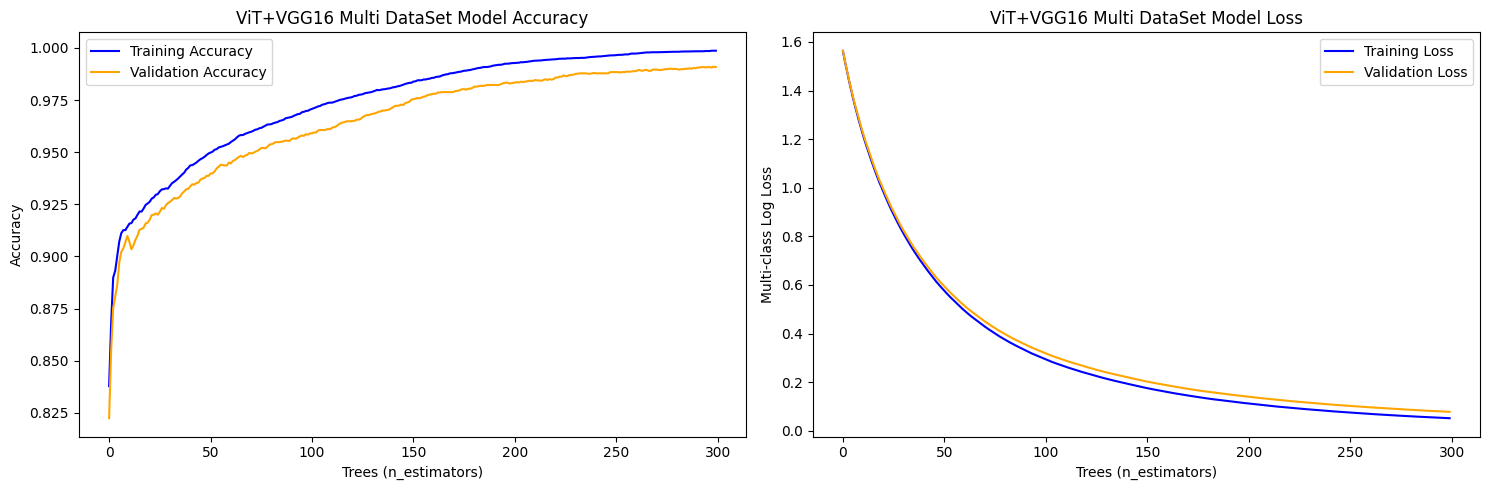

In [18]:
results = xgb_model.evals_result()

train_acc = [1 - x for x in results['validation_0']['merror']]
test_acc = [1 - x for x in results['validation_1']['merror']]

train_loss = results['validation_0']['mlogloss']
test_loss = results['validation_1']['mlogloss']

epochs = len(train_loss)
x_axis = range(0, epochs)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(x_axis, train_acc, label='Training Accuracy', color='blue')
plt.plot(x_axis, test_acc, label='Validation Accuracy', color='orange')
plt.legend(loc="best")
plt.xlabel('Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('ViT+VGG16 Multi DataSet Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(x_axis, train_loss, label='Training Loss', color='blue')
plt.plot(x_axis, test_loss, label='Validation Loss', color='orange')
plt.legend(loc="best")
plt.xlabel('Trees (n_estimators)')
plt.ylabel('Multi-class Log Loss')
plt.title('ViT+VGG16 Multi DataSet Model Loss')

plt.tight_layout()
plt.show()

**Evaluation and Saving**

In [19]:
# Get predictions for the entire test set
y_pred = xgb_model.predict(X_test_scaled)

# If you want to see the accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")

✅ Test Accuracy: 99.08%


**Confusion Matrix**


✅ Classification Report:
              precision    recall  f1-score   support

  cervix_dyk       0.99      0.99      0.99      1000
  cervix_koc       0.99      0.97      0.98      1000
  cervix_mep       0.98      1.00      0.99      1000
  cervix_pab       1.00      1.00      1.00      1000
  cervix_sfi       0.99      1.00      0.99      1000

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



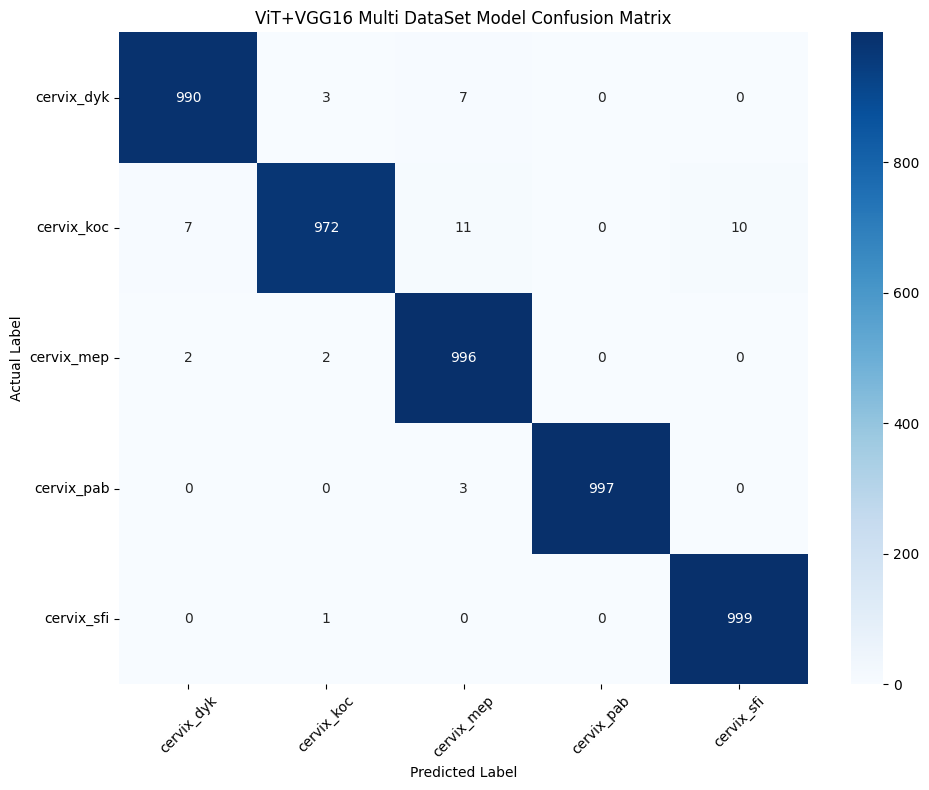

In [20]:
y_pred = xgb_model.predict(X_test_scaled)
class_names = label_encoder.classes_

print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ViT+VGG16 Multi DataSet Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# SAVE

In [21]:
# CHANGE: Update filenames to reflect Multi-Cancer + ViT + your backbone name

xgb_model.save_model("ViT+VGG16_multicancer_xgboost_hybrid_optimized.json")
joblib.dump(scaler,        "ViT+VGG16_multicancer_scaler_optimized.pkl")
joblib.dump(label_encoder, "ViT+VGG16_multicancer_label_encoder_optimized.pkl")
joblib.dump(pca,           "ViT+VGG16_multicancer_pca_model.pkl")

print("Optimized Pipeline saved successfully.")

Optimized Pipeline saved successfully.


# TEST

In [22]:
# CHANGE: This is the full updated cross-validation cell for Multi-Cancer ViT notebook

SIPAKMED_PATH = '/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed'

sipakmed_label_map = {
    'im_Dyskeratotic'             : 'cervix_dyk',
    'im_Koilocytotic'            : 'cervix_koc',
    'im_Metaplastic'             : 'cervix_mep',
    'im_Parabasal'               : 'cervix_pab',
    'im_Superficial-Intermediate': 'cervix_sfi'
}

sipakmed_paths = glob.glob(os.path.join(SIPAKMED_PATH, '**', '*.*'), recursive=True)
sipakmed_paths = [p for p in sipakmed_paths if p.lower().endswith(('.bmp', '.jpg', '.png'))]

sipakmed_raw_labels = [p.split('/')[-2] for p in sipakmed_paths]
sipakmed_labels     = [sipakmed_label_map.get(l, l) for l in sipakmed_raw_labels]

sipakmed_df = pd.DataFrame({'filename': sipakmed_paths, 'label': sipakmed_labels})
sipakmed_df = sipakmed_df[sipakmed_df['label'].isin(label_encoder.classes_)]
sipakmed_df['label_encoded'] = label_encoder.transform(sipakmed_df['label'])

print(f"SIPaKMeD images loaded: {len(sipakmed_df)}")
print("Class Distribution:\n", sipakmed_df['label'].value_counts())

SIPaKMeD images loaded: 966
Class Distribution:
 label
cervix_mep    271
cervix_koc    238
cervix_dyk    223
cervix_sfi    126
cervix_pab    108
Name: count, dtype: int64


In [23]:
# Extract deep features from SIPaKMeD using BOTH extractors

# 1. VGG16 generator + features
sipakmed_rn_gen = rn_datagen.flow_from_dataframe(
    sipakmed_df, x_col='filename', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

print("Extracting Xception features from SIPaKMeD...")
X_sipakmed_rn = rn_extractor.predict(sipakmed_rn_gen, verbose=1)

# 2. ConvNeXt generator + features
sipakmed_cn_gen = cn_datagen.flow_from_dataframe(
    sipakmed_df, x_col='filename', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

print("Extracting ConvNeXtTiny features from SIPaKMeD...")
X_sipakmed_cn = cn_extractor.predict(sipakmed_cn_gen, verbose=1)

# 3. Fuse exactly like training (VGG16 512 + ConvNeXt 768 = 1280)
X_sipakmed_deep = np.hstack((X_sipakmed_rn, X_sipakmed_cn))

# 4. Apply SAME PCA fitted on Multi-Cancer (do NOT refit)
X_sipakmed_deep_pca = pca.transform(X_sipakmed_deep)
print(f"Deep features shape: {X_sipakmed_deep_pca.shape}")

Found 966 validated image filenames belonging to 5 classes.
Extracting Xception features from SIPaKMeD...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step
Found 966 validated image filenames belonging to 5 classes.
Extracting ConvNeXtTiny features from SIPaKMeD...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step
Deep features shape: (966, 128)


In [24]:
# Extract handcrafted features from SIPaKMeD
print("Extracting GLCM & DWT features from SIPaKMeD...")
hc_features_sipakmed = np.array([
    extract_handcrafted_features(p) for p in tqdm(sipakmed_df['filename'])
])

Extracting GLCM & DWT features from SIPaKMeD...


100%|██████████| 966/966 [00:42<00:00, 22.99it/s]



✅ Cross-Dataset Accuracy on SIPaKMeD: 82.30%

✅ Classification Report (SIPaKMeD):
              precision    recall  f1-score   support

  cervix_dyk       0.88      0.71      0.79       223
  cervix_koc       0.90      0.71      0.80       238
  cervix_mep       0.68      0.86      0.76       271
  cervix_pab       0.93      1.00      0.96       108
  cervix_sfi       0.91      0.98      0.95       126

    accuracy                           0.82       966
   macro avg       0.86      0.85      0.85       966
weighted avg       0.84      0.82      0.82       966



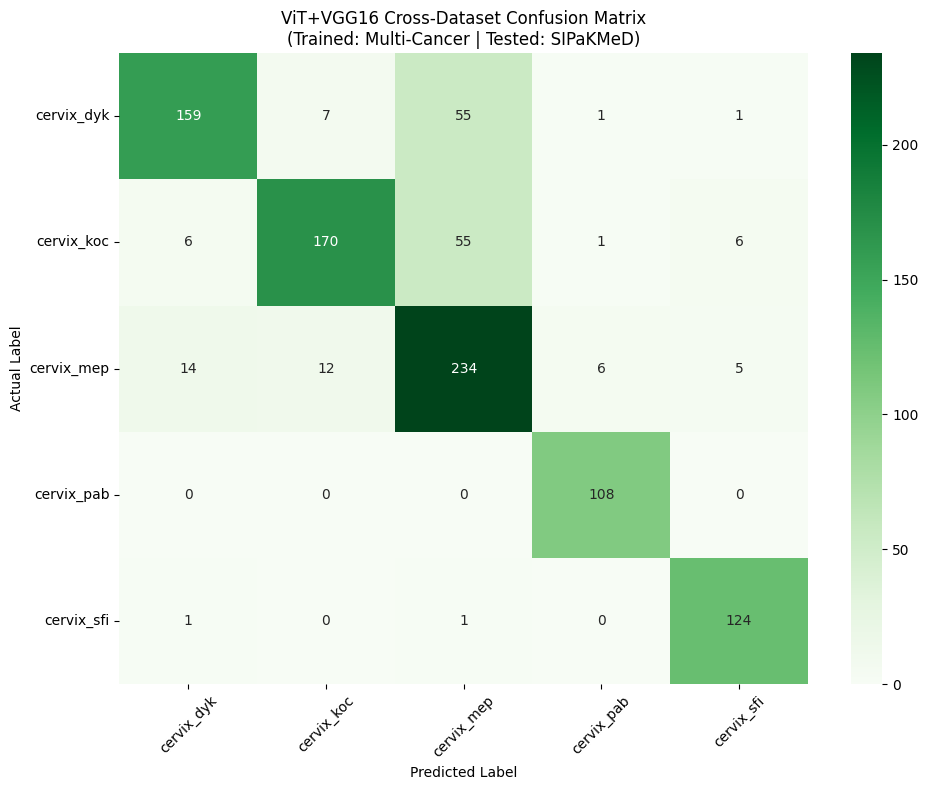

In [25]:
# Fuse + Scale using the SAME scaler fitted on Multi-Cancer
X_sipakmed_fused  = np.hstack((X_sipakmed_deep_pca, hc_features_sipakmed))
X_sipakmed_scaled = scaler.transform(X_sipakmed_fused)  # transform only, NOT fit_transform

y_sipakmed = sipakmed_df['label_encoded'].values

# Predict
y_sipakmed_pred = xgb_model.predict(X_sipakmed_scaled)

# Results
accuracy_sipakmed = accuracy_score(y_sipakmed, y_sipakmed_pred)
print(f"\n✅ Cross-Dataset Accuracy on SIPaKMeD: {accuracy_sipakmed * 100:.2f}%")

print("\n✅ Classification Report (SIPaKMeD):")
print(classification_report(y_sipakmed, y_sipakmed_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm_sipakmed = confusion_matrix(y_sipakmed, y_sipakmed_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sipakmed, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('ViT+VGG16 Cross-Dataset Confusion Matrix\n(Trained: Multi-Cancer | Tested: SIPaKMeD)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()